# AG-HYPOPT · Trial 10

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Nine trials are registered; cell 2 reports `phase = trials` (9/5), so proposals carry expected-improvement (ei) values. **Best = trial_08** (objective 0.1099). Ranking with mu travel = `lr_mu*(1 - mu_anneal/2)`:

- **trial_08 (0.1099, best, 0 div):** `lr_mu=0.1616`, `mu_anneal=0.3475`, `lr_gamma=0.4157`, `gamma_anneal=0.5318` (travel 0.134). mu 76.5%, gamma 23.1%; 1nW high-T mu undershoot essentially gone.
- **trial_09 (0.1126, 0 div):** travel 0.123, refinement next to trial_08; mu 71.1%, gamma 23.7%.
- **trial_01 (0.1127, 0 div):** travel 0.120; mu 77.1%, gamma 21.5%.
- **trial_05 (0.1135, 0 div):** travel 0.088; mu 56.6%, gamma 23.8%.
- **trial_07 (0.1140, 0 div):** travel 0.097; mu 62.0%, gamma 21.6%.
- **trial_06 (0.1188, 0 div):** travel 0.082; mu 57.6%, gamma 24.1%.
- **trials 03 / 04 / 02 (0.1362 / 0.1418 / 0.1449, 1 div each):** travels 0.074 / 0.074 / 0.264; all diverged at 1nW T05.

Where the campaign stands: six runs (01, 05, 06, 07, 08, 09) are divergence-free and span travels 0.082-0.134 with objectives 0.1099-0.1188. The most recent signal (trials 08, 09) is that the *upper* edge of this band is best — trial_08 at travel 0.134 fixed the heavily-weighted 1nW high-T mu undershoot and took the campaign best to 0.1099. The remaining errors in the best runs are the 3nW high-T mu undershoot and the low-T gamma under-recovery. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_10'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (9/5 trials)
ID |     ei | params
 1 | 3.8296 | {"gamma_anneal": 0.5025505497271179, "lr_gamma": 0.4224170372380301, "lr_mu": 0.10906312447513182, "mu_anneal": 0.3574419583413484}
 2 | 3.8418 | {"gamma_anneal": 0.4357177858352299, "lr_gamma": 0.39518631549860245, "lr_mu": 0.10420748410340926, "mu_anneal": 0.3343983243377739}
 3 | 0.2280 | {"gamma_anneal": 0.6710221899395438, "lr_gamma": 0.9112023183072805, "lr_mu": 0.4273536762032751, "mu_anneal": 0.9698303682063217}
 4 | 0.0406 | {"gamma_anneal": 0.3812339195727778, "lr_gamma": 0.6255717460286923, "lr_mu": 0.1228102159058821, "mu_anneal": 0.24977551939628317}
 5 | 3.5280 | {"gamma_anneal": 0.45735073624218125, "lr_gamma": 0.19194415555193883, "lr_mu": 0.1282158641077907, "mu_anneal": 0.32798345746136326}
 6 | 3.8925 | {"gamma_anneal": 0.5214574375871789, "lr_gamma": 0.44717373017471373, "lr_mu": 0.1193843757751678, "mu_anneal": 0.33762705247345415}
 7 | 1.9849 | {"gamma_anneal": 0.40156238320473203, "lr_gamma": 0.77887

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (9 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 6: **ei 3.89** — `lr_mu=0.119`, `mu_anneal=0.338` (travel **0.099**), `lr_gamma=0.447`, `gamma_anneal=0.521`.
- candidate 2: ei 3.84 — `lr_mu=0.104`, `mu_anneal=0.334` (travel 0.087), `lr_gamma=0.395`, `gamma_anneal=0.436`.
- candidate 1: ei 3.83 — `lr_mu=0.109`, `mu_anneal=0.357` (travel 0.090), `lr_gamma=0.422`, `gamma_anneal=0.503`.
- candidate 5: ei 3.53 — `lr_mu=0.128`, `mu_anneal=0.328` (travel 0.107), `lr_gamma=0.192` (very low), `gamma_anneal=0.457`.
- candidate 7: ei 1.98 — `lr_mu=0.176`, `mu_anneal=0.343` (travel 0.146), `lr_gamma=0.779`, `gamma_anneal=0.402`.

The three highest-ei candidates (6, 2, 1) cluster tightly in the divergence-free band at travel 0.087-0.099 with `lr_gamma` ~0.40-0.45 and `gamma_anneal` ~0.44-0.52. Candidate 6 has the highest ei; its travel (0.099) sits between trial_07's (0.097) and trial_01's (0.120), and its gamma knobs are essentially trial_06/07's proven-safe values — i.e. it refines the lower-middle of the good band with a gamma schedule that never diverged. Per the algorithm's own guidance, the highest ei is the natural pick. I note that trials 08/09 suggest the *upper* edge of the band is slightly better (trial_07 candidate 7 here extends travel to 0.146), but candidate 7's ei is much lower and nothing distinguishes its gamma schedule from already-tested points, so the informed choice remains the highest-ei, proven-safe region — this also keeps the surrounding band sampled finely for the surrogate.

I choose candidate 6 (6 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 6            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.5214574375871789, 'lr_gamma': 0.44717373017471373, 'lr_mu': 0.1193843757751678, 'mu_anneal': 0.33762705247345415}
Running  1nW Trans05 ... 

μ 9.39 -> 11.26 | γ 8.5 -> 4.41 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 37.33 | γ 8.5 -> 5.99 | NLL 4.81


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 59.77 | γ 14.1 -> 2851123486655240.00 | NLL 3.12


Running 3nW Trans100 ... 

μ 175.71 -> 105.09 | γ 14.1 -> 14.08 | NLL 3.28



Total: 7.3 min


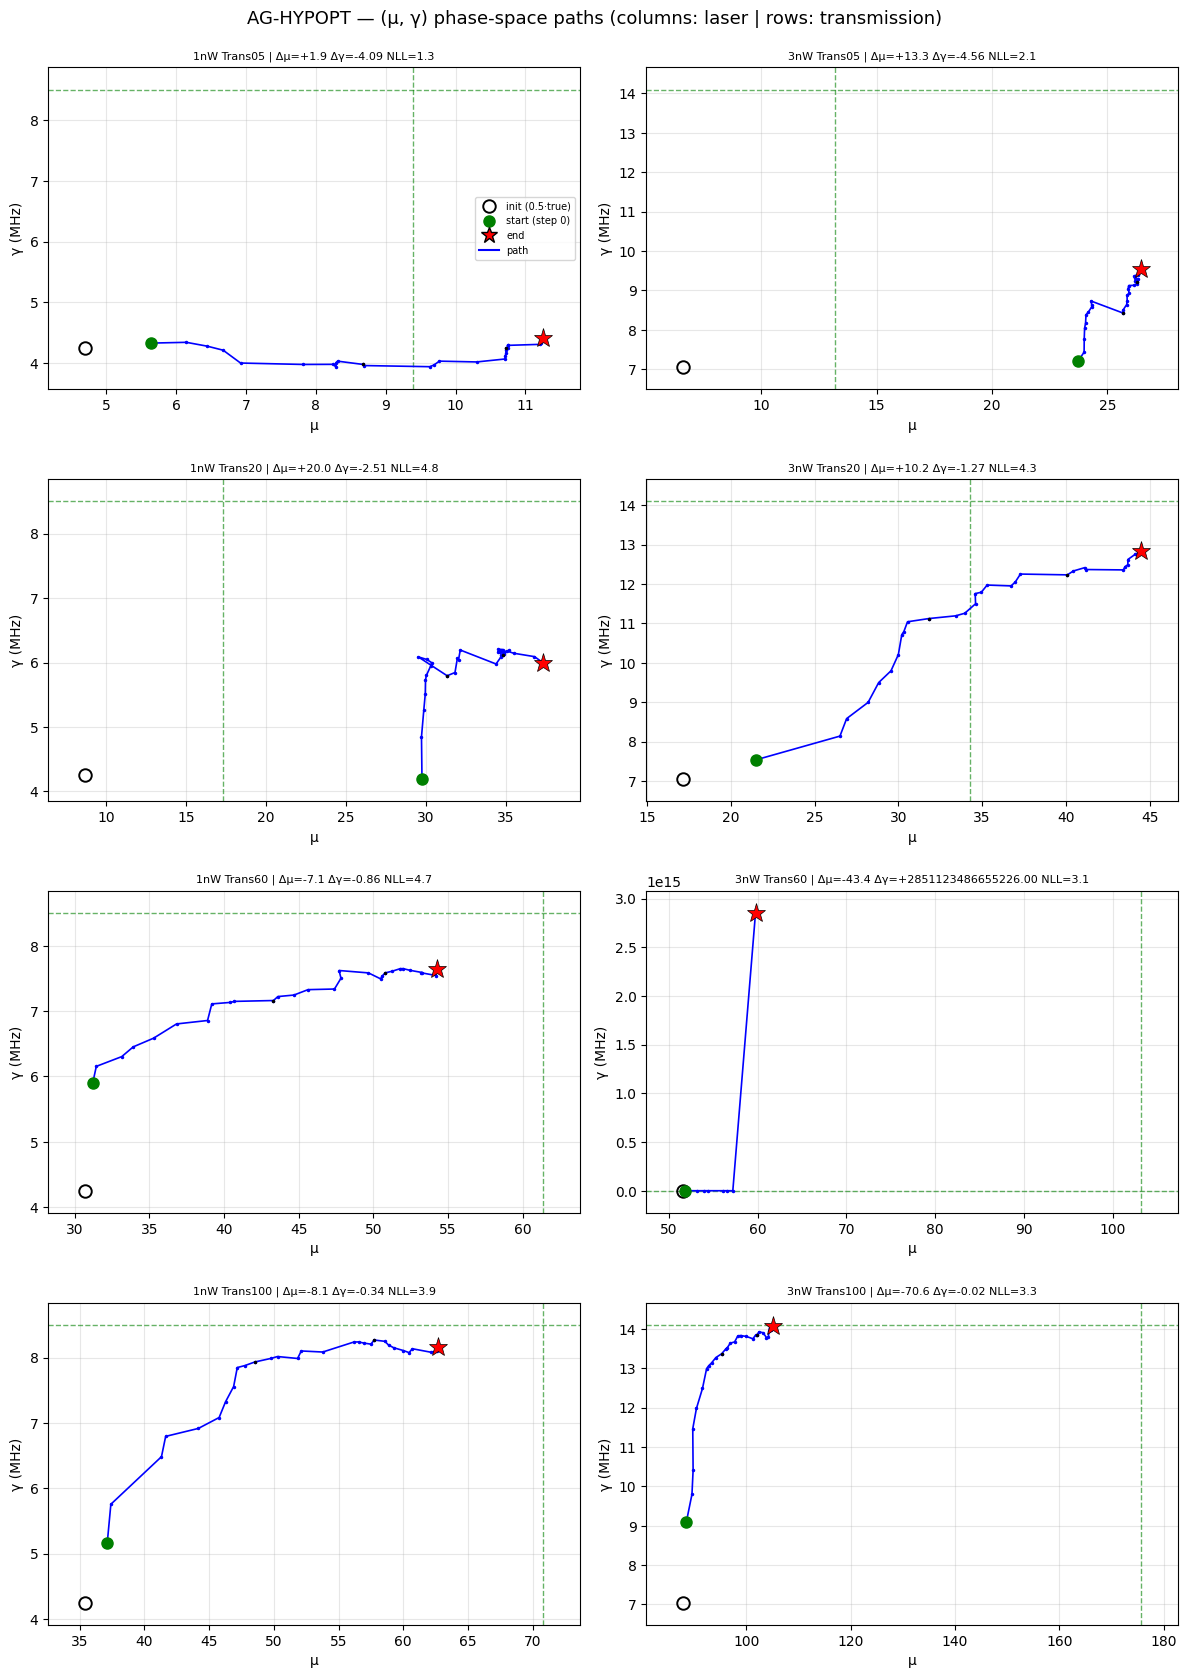

trial finished in 7.3 min
objective = 0.1975 ± 0.0951
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   11.26   +19.8 |     8.50    4.41   -48.2
1nW Trans20       17.32   37.33  +115.6 |     8.50    5.99   -29.5
1nW Trans60       61.37   54.28   -11.6 |     8.50    7.64   -10.1
1nW Trans100       70.82   62.71   -11.4 |     8.50    8.16    -4.0
3nW Trans05       13.20   26.48  +100.5 |    14.10    9.54   -32.4
3nW Trans20       34.28   44.51   +29.8 |    14.10   12.83    -9.0
3nW Trans60 !D   103.20   59.77   -42.1 |    14.102851123486655240.00+20220733947909408.0
3nW Trans100      175.71  105.09   -40.2 |    14.10   14.08    -0.2

weighted objective (T-graded, cap=1.0) = 0.1975 | diverged cells: 1
μ: RMSE 30.971 (rel 59.6%, bias -10.484) | γ: RMSE 1008024375707071.625 (rel 7149109047567884.0%, bias +356390435831901.500)


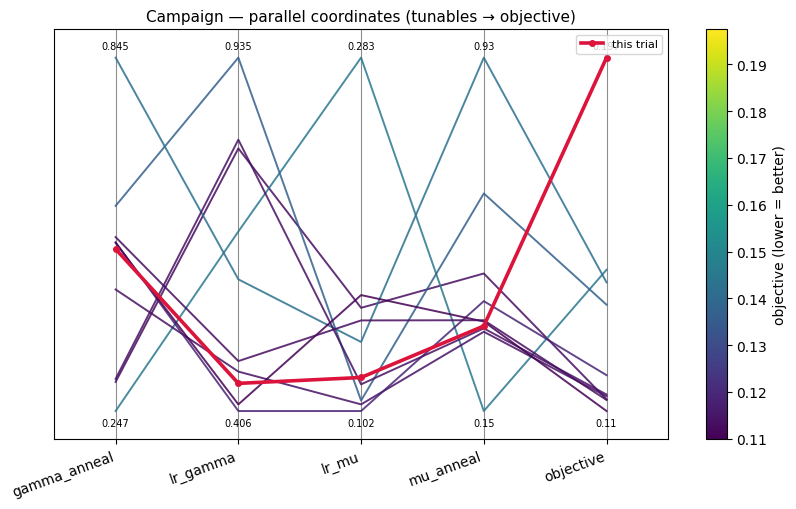

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 10 ran the highest-EI candidate (candidate 6, ei=3.89): `lr_mu=0.1194`, `mu_anneal=0.3376` (effective mu travel 0.099), `lr_gamma=0.4472`, `gamma_anneal=0.5215`. It completed in 7.3 min with objective **0.1975 +/- 0.0951** and **1 diverged cell** — the worst run of the campaign. Ranking: trial_08 0.1099 < trial_09 0.1126 < trial_01 0.1127 < trial_05 0.1135 < trial_07 0.1140 < trial_06 0.1188 < trial_03 0.1362 < trial_04 0.1418 < trial_02 0.1449 < **trial_10 0.1975**.

Aggregate accuracy: **mu rel-RMSE 59.6%** (RMSE 30.97, bias -10.48) — a typical small-travel mu; **gamma rel-RMSE** is dominated by the diverged cell (raw RMSE 1.0e15).

Per-cell relative errors (3nW T60 gamma is the diverged value):
- **mu:** 1nW T05 +19.8%, T20 +115.6%, T60 -11.6%, T100 -11.4% | 3nW T05 +100.5%, T20 +29.8%, **T60 -42.1%** (diverged on gamma), T100 -40.2%.
- **gamma:** 1nW T05 -48.2%, T20 -29.5%, T60 -10.1%, T100 -4.0% | 3nW T05 -32.4%, T20 -9.0%, **T60 diverged (2.85e15)**, T100 -0.2%.

This trial is important because it broke the pattern: the gamma blow-up did **not** occur at 1nW T05 (the cell that diverged in trials 02/03/04) but at **3nW T60**, a high-transmission, heavily-weighted cell (w=0.70), where the mu estimate also collapsed (-42.1%). In other respects the run is a normal small-travel run (travel 0.099, close to trial_07's 0.097) with `lr_gamma=0.447` — even lower than several runs that stayed finite. So the divergence is not localised to one fragile low-count cell, and not simply a function of the gamma step size; it appears to be a sporadic instability of the small-travel regime that can strike a different, high-weight cell and cost the objective heavily (the three other 3nW cells are fine).

**Summary:** Trial 10 (lr_mu=0.1194, mu_anneal=0.3376, lr_gamma=0.4472, gamma_anneal=0.5215): objective 0.1975 +/- 0.0951 with 1 diverged cell (3nW T60, gamma 2.85e15) - the worst run of the campaign; the highest-EI proposal diverged at a new, heavily-weighted high-transmission cell, so gamma instability is not confined to 1nW T05.
**Key insight:** The gamma blow-up is not tied to the low-T/1nW cell: it appeared at 3nW T60 here (with lr_gamma=0.447, lower than several finite runs), so the divergence is a sporadic instability of the small-travel regime that can hit a different, high-weight cell.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** With divergences now seen at 1nW T05 (trials 02/03/04) and 3nW T60 (trial 10), each under different gamma knobs, the instability looks sporadic rather than schedule-determined. The two best runs (08, 09) are at the larger-travel end of the band and both stayed finite, which may or may not be causal. This strengthens the case for a structural safeguard/lever outside this campaign's hyperparameter scope (per-experiment step, or a divergence-aware schedule); recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 10 (lr_mu=0.1194, mu_anneal=0.3376, lr_gamma=0.4472, gamma_anneal=0.5215): objective 0.1975 +/- 0.0951 with 1 diverged cell (3nW T60, gamma 2.85e15) - the worst run of the campaign; the highest-EI proposal diverged at a new, heavily-weighted high-transmission cell, so gamma instability is not confined to 1nW T05"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The gamma blow-up is not tied to the low-T/1nW cell: it appeared at 3nW T60 here (with lr_gamma=0.447, lower than several finite runs), so the divergence is a sporadic instability of the small-travel regime that can hit a different, high-weight cell"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_10 | current best: trial_08


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_11.ipynb. Open it and follow its cells from the top.
